<class 'pandas.core.series.Series'>


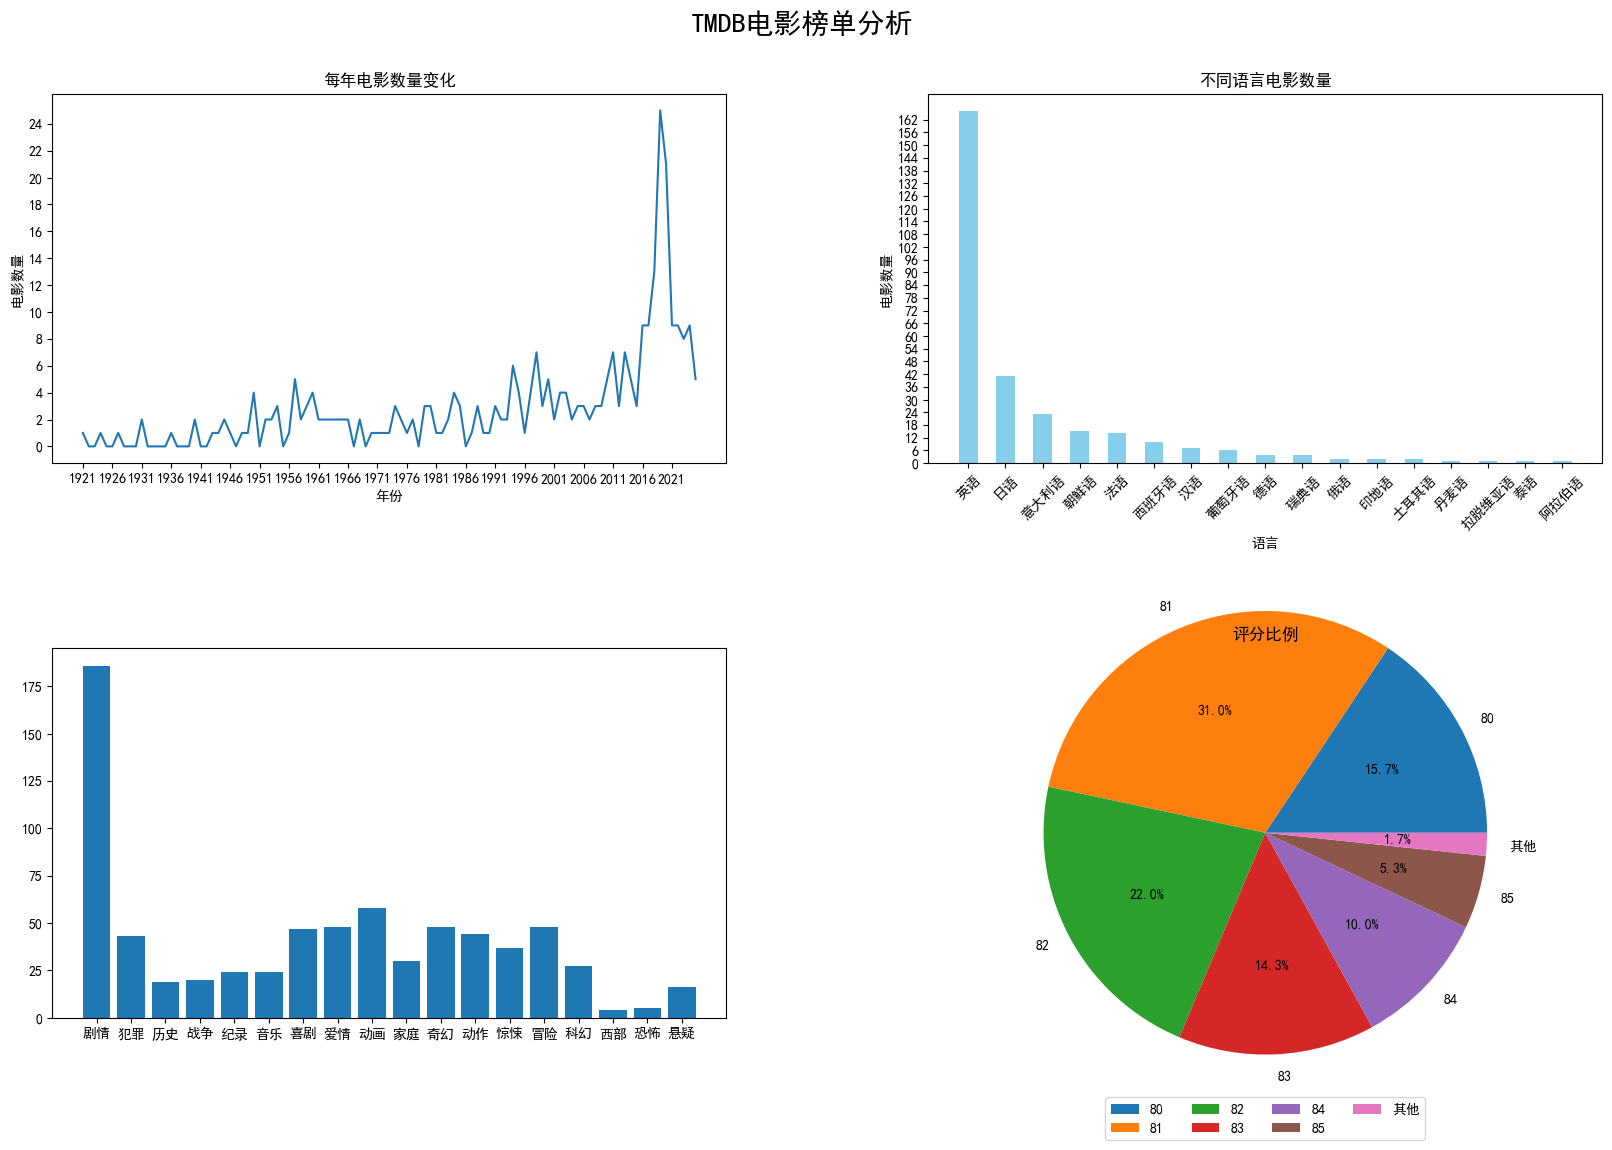

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from numpy.f2py.cfuncs import typedefs
from pandas.core.dtypes.common import INT64_DTYPE

# 显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

fig,axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12),dpi=100)
fig.suptitle('TMDB电影榜单分析', fontsize=20,x = 0.5,y=0.95)
fig.subplots_adjust(wspace=0.3, hspace=0.5)

axes1: plt.Axes = axes[0][0]
axes2: plt.Axes = axes[0][1]
axes3: plt.Axes = axes[1][0]
axes4: plt.Axes = axes[1][1]

# 读取数据
data = pd.read_csv('./Data/movies.csv',usecols=['电影名','年份','上映时间','类型','时长','评分','语言'],dtype={'年份':'Int64'})

# 1. 需求一：统计TOP300的电影中，每一年上映的电影数量的变化。(折线图)
# 1.1 缺失值、异常值处理
# data.isnull().sum()
data['年份'] = data['年份'].fillna(data['上映时间'].str[:4])

# 分组统计
year_count = data.groupby('年份')['年份'].count()

# 组装数据
year = [i for i in range(year_count.index.min(),year_count.index.max()+1)]
count = [year_count.get(i,0) for i in year]
# 绘制折线图
axes1.set_xlabel('年份')
axes1.set_ylabel('电影数量')
axes1.set_title('每年电影数量变化')
axes1.set_xticks(range(min(year),max(year)+1,5))
axes1.set_yticks(range(0,max(count)+1,2))
axes1.plot(year,count)

# 2. 需求二:统计不同语言的电影数量（柱状图）
language_count = data.groupby('语言')['语言'].count().sort_values(ascending=False)
language = [i for i in language_count.index]
count = [language_count.get(i,0) for i in language]


axes2.set_xlabel('语言')
axes2.set_ylabel('电影数量')
axes2.set_title('不同语言电影数量')
axes2.set_xticks(range(len(language)))
axes2.set_yticks(range(0,max(count)+1,6))
axes2.tick_params(axis='x',labelrotation=45)
axes2.bar(language,count,width=0.5,color='skyblue')


# 3. 需求三:统计对比不同类型电影数量（柱状图）
type_count = {}
for types in data['类型'].str.split(','):
    for type1 in types:
        if type1 in type_count:
            type_count[type1] += 1
        else:
            type_count[type1] = 1
x = [key for key in type_count.keys()]
y = [key for key in type_count.values()]
axes3.bar(x,y)



# 4. 需求四:统计对比各个电影评分的比例（饼状图）
score_count = data.groupby('评分')['评分'].count()

# 合并小数据
print(type(score_count))
total = score_count.sum()
large_score: pd.Series = score_count.loc[score_count >= total*0.02]
small_score: pd.Series = score_count.loc[score_count < total*0.02]
large_score['其他'] = small_score.sum()
score_count = large_score

scores = score_count.index.tolist()
values = score_count.values.tolist()
axes4.pie(values,labels=scores,autopct='%1.1f%%',startangle=0,radius=1.5)
axes4.set_title('评分比例')

axes4.legend(loc='lower center',ncol=4,bbox_to_anchor=(0.5,-0.35))

# 保存图片
plt.savefig('./Data/movies.png')

plt.show()